# Modeling Summary


<u>Outline</u>

1. Modeling
    1. Logistic Regression
        1. Baseline model
        2. Improvements
    2. Decision Tree
    3. Random Forest
    4. Histogram-based Gradient Boosting Classification Tree
    5. XGBoost

2. Model Comparisons
    1. AUC score
    2. Cross Validation Score

3. Best Model Analysis
    1. ROC Curve
    2. Confusion Matrix

4. Performance on Test Data

In [1]:
# Import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score,roc_curve,accuracy_score,confusion_matrix
from sklearn.model_selection import cross_val_score,train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator,ClassifierMixin
from xgboost import XGBClassifier

sns.set_style("whitegrid")

In [2]:
# Load in training dataframe
path_to_train = "data/data_cleaned.csv.zip"
train_full_df = pd.read_csv(path_to_train)

# Load in testing dataframe
path_to_test = "data/test_data_cleaned.csv.zip"
test_full_df = pd.read_csv(path_to_test)

# Eliminate any matches where one player quits prematurely
train_complete_matches = train_full_df[(train_full_df['duration'] > 60) & ((train_full_df["p1_revealed_team_size"] > 2) | (train_full_df["p2_revealed_team_size"] > 2))]
test_complete_matches = test_full_df[(test_full_df['duration'] > 60) & ((test_full_df["p1_revealed_team_size"] > 2) | (test_full_df["p2_revealed_team_size"] > 2))]

# Only use matches for which we know the players' elo ratings (so that we can use elo_diff as a feature)
train_df = train_complete_matches[train_complete_matches['p1elo0'] > 0].copy()
test_df = test_complete_matches[test_complete_matches['p1elo0'] > 0].copy()

# Set Elo differential as a column for ease of reference
train_df['elo_diff'] =  train_df['p1elo0'] - train_df['p2elo0']
test_df['elo_diff'] =  test_df['p1elo0'] - test_df['p2elo0']

# Section 1: Modeling
## 1.1 Logistic Regression
### 1.1.1 Baseline Model

In a sense, the null hypothesis is that player skill is the driving factor in determining the battle's outcome.  Hence, our baseline model should be based only on player skill, which is represented by their Elo rating.  Since Elo ratings are designed to give probabilistic predictions of outcomes based on a certain formula, we do not need to train a logistic regression on the rating differential, and instead, we use a custom predictor which has the formula built into it.  (This predictor is a logistic regression, just with fixed paramaters that do not need to be fit.)

In [3]:
class CustomEloPredictor(BaseEstimator, ClassifierMixin):
    _estimator_type = "classifier"

    def __init__(self, scale=400):
        self.scale = scale

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        elo_diff = X[:, 0].astype(float)
        p = 1 / (1 + 10 ** (-elo_diff / self.scale))
        return np.column_stack([1 - p, p])

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        preds = (probs >= 0.5).astype(int)
        return self.classes_[preds]

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"
        return tags

In [4]:
########## BASELINE MODEL ##########
base_feature = ["elo_diff"]
X_train_base = train_df[base_feature]
y_train = train_df["p1_win"]

custom_baseline = CustomEloPredictor()


### 1.1.2 Improvements

Improvements to the baseline largely come from from the p1_total_adv feature, but there are a few useful traits in there as well.  Notice the difference between the unbiased and the biased linear regression.  The biased linear regression ends up obtaining more accuracy, but is heavily biased against player 1 because the training set features more battles where player 1 loses than where player 1 wins.  While there may be good reason for this (for some reason, Showdown has a light tendency to put the player with the lower Elo rating in the player 1 slot), the model is far more biased than is reasonable, so we add an unbiased model to the mix.

In [5]:
########## IMPROVED MODEL ##########

# This is the full set of features that improve some models.  Not every model uses all of these features.  The best model uses all but total_stat_diff and type_diversity_diff.
features = [
    "elo_diff",
    "p1_total_adv",
    "total_stat_diff",
    "type_diversity_diff",
    "num_move_boosters_diff",
    "num_boosting_abilities_diff"
]
X_train = train_df[features]

lr_unbiased = Pipeline([
    ('scale',StandardScaler()),
    ('lr',LogisticRegression(max_iter=10000,C=np.inf,fit_intercept=False))
])

lr_biased = LogisticRegression(max_iter=10000,C=np.inf,fit_intercept=True)

## 1.2 Decision Tree

In [6]:
# Do a grid search for decision tree parameters
dt_param_grid = {
    "max_depth": [3, 5, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid=dt_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best parameters:")
print(dt_grid.best_params_)

Best parameters:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 20}


In [7]:
dt = Pipeline([
    ('scale',StandardScaler()),
    ('dt',DecisionTreeClassifier(
    random_state=0,
    max_depth = 3,
    min_samples_leaf= 1,
    min_samples_split= 20))
])

## 1.3 Random Forest

In [8]:
# Do a grid search for random forest parameters
rf_param_grid = {
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [5, 10, 20],
    "n_estimators": [200, 500, 800]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'max_depth': 4, 'min_samples_leaf': 20, 'n_estimators': 500}


In [9]:
rf = Pipeline([
    ('scale',StandardScaler()),
    ('rf',RandomForestClassifier(
    max_depth=4,
    min_samples_leaf=20,
    n_estimators=500,
    random_state=0))
])

## 1.4 Histogram-based Gradient Boosting Classification Tree

In [10]:
# Do a grid search for HistGradientBoosting parameters
hgb_param_grid = {
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [5, 10, 20],
    "max_iter": [100, 200, 500] 
}

grid = GridSearchCV(
    HistGradientBoostingClassifier(random_state=0),
    param_grid=hgb_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'max_depth': 4, 'max_iter': 100, 'min_samples_leaf': 20}


In [11]:
hgb = Pipeline([
    ('scale',StandardScaler()),
    ('hgb',HistGradientBoostingClassifier(
    max_depth=4,
    max_iter=100,
    min_samples_leaf=20,
    random_state=0))
])

## 1.5 XGBoost

In [12]:
# Do a grid search for XGBoost parameters
xgb_param_grid = {
    "max_depth": [4, 6, 8, 10],
    "min_child_weight": [5, 10, 20], 
    "n_estimators": [200, 500, 800] 
}

grid = GridSearchCV(
    XGBClassifier(random_state=0),
    param_grid=xgb_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'max_depth': 4, 'min_child_weight': 20, 'n_estimators': 200}


In [13]:
xgb = Pipeline([
    ('scale',StandardScaler()),
    ('xgb',XGBClassifier(
    max_depth=4,
    min_child_weight=20,
    n_estimators=200,
    random_state=0))
])

# Section 2: Model Comparisons

For each of the models above, we compute their cross-validation accuracies and confusion matrices.

We chose accuracy as our primary metric.  Log-loss isn't a poor metric, but the difference in log-loss is very small between the models.  Additionally, the accuracy scores and areas under the receiver operating characteristic curves are quite close for these models, but accuracy is simpler to communicate.

Confusion matrices played an important role in our analysis as well.  Notice that there is no meaningful difference between Type 1 and Type 2 errors.  Predicting that player 1 will win when player 2 actually does is essentially the same error as predicting that player 2 will win when player 1 actually does.  As a consequence, the best model should have a roughly symmetric confusion matrix.

In [14]:
models = [
    ("custom baseline",custom_baseline,X_train_base),
    ("unbiased logistic regression", lr_unbiased,X_train[['elo_diff','p1_total_adv','num_move_boosters_diff','num_boosting_abilities_diff']]),
    ("biased logistic regression", lr_biased, X_train),
    ("decision tree", dt, X_train),
    ("random forest", rf, X_train),
    ("histogram Gradient Boosting", hgb, X_train),
    ("XGBoost", xgb, X_train)
]

skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=207)

for i in range(len(models)):
    model_name = models[i][0]
    model = models[i][1]
    data_frame = models[i][2]
    # get cross-validation scores
    cvscore = cross_val_score(model,data_frame,y_train,cv=skf,n_jobs=-1,scoring="accuracy")
    print(f"The average accuracy score for the {model_name} model is {cvscore.mean()} +/- {cvscore.std(ddof=1)}")

    # get confusion matrices for a basic train_test_split
    data_frame_tt,data_frame_val,y_tt,y_val = train_test_split(data_frame,y_train,test_size=0.2,shuffle=True,random_state=207,stratify=y_train)
    model.fit(data_frame_tt,y_tt)
    preds = model.predict(data_frame_val)
    cm = confusion_matrix(y_val,preds,normalize='all')
    print(f"The confusion matrix for the {model_name} model is")
    print(cm)
    print()

The average accuracy score for the custom baseline model is 0.5213054149775604 +/- 0.007281051908036138
The confusion matrix for the custom baseline model is
[[0.30867347 0.21513605]
 [0.25085034 0.22534014]]

The average accuracy score for the unbiased logistic regression model is 0.5306611457854089 +/- 0.009905927419258501
The confusion matrix for the unbiased logistic regression model is
[[0.2797619  0.24404762]
 [0.22066327 0.25552721]]

The average accuracy score for the biased logistic regression model is 0.5412944846164753 +/- 0.006352937502854174
The confusion matrix for the biased logistic regression model is
[[0.40518707 0.11862245]
 [0.3295068  0.14668367]]

The average accuracy score for the decision tree model is 0.533298827825473 +/- 0.01094706788653725
The confusion matrix for the decision tree model is
[[0.4247449  0.09906463]
 [0.36394558 0.1122449 ]]

The average accuracy score for the random forest model is 0.532022883589846 +/- 0.007415854383348429
The confusion mat

Our best model appears to be the unbiased logistic regression.  While other models have higher accuracy scores (most notably the full biased logistic regression), their confusion matrices are horribly lopsided, with the full biased linear regression predicting that player 1 will win only 23% of the time!  In contrast, the full unbiased linear regression has a nearly symmetric confusion matrix, and it still improves upon the baseline model's accuracy by 1.3% on average.

In [15]:
# Choose best model
best_model_index = 1
best_model_name = models[best_model_index][0]
best_model = models[best_model_index][1]
X_train = models[best_model_index][2]
best_model.fit(X_train,y_train)

print(best_model_name)

unbiased logistic regression


# Section 3: Best Model Analysis

We now take a look at some more details of how our unbiased full linear regression performs.

## 3.1 ROC Curve

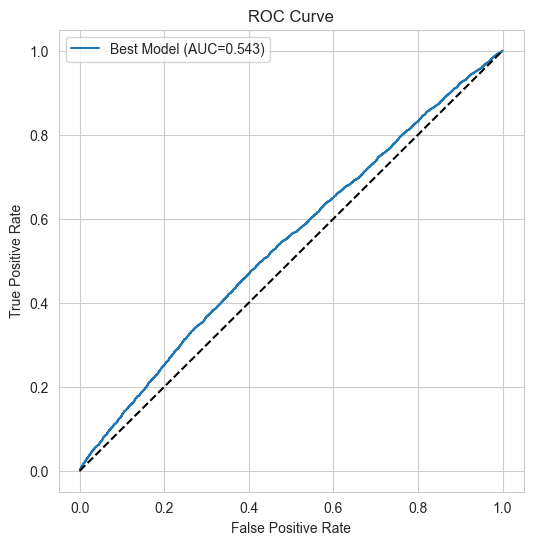

In [16]:
# Set up ROC curve
prob = best_model.predict_proba(X_train)[:,1]
fpr, tpr, _ = roc_curve(y_train, prob)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"Best Model (AUC={roc_auc_score(y_train, prob):.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## 3.2 Confusion Matrix

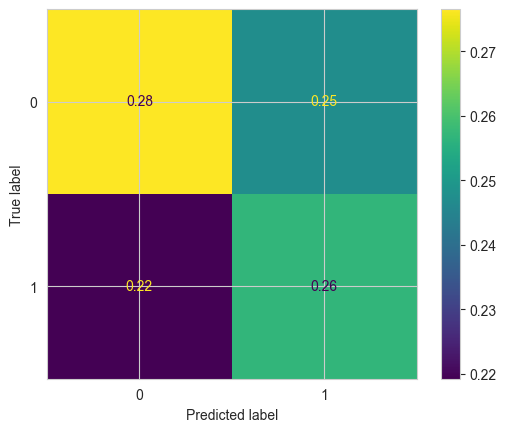

In [17]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_train,
    y_train,
    normalize='all'
)

## 3.3 Feature Separation

Let's see if our best model is predicting as it should along the various features.

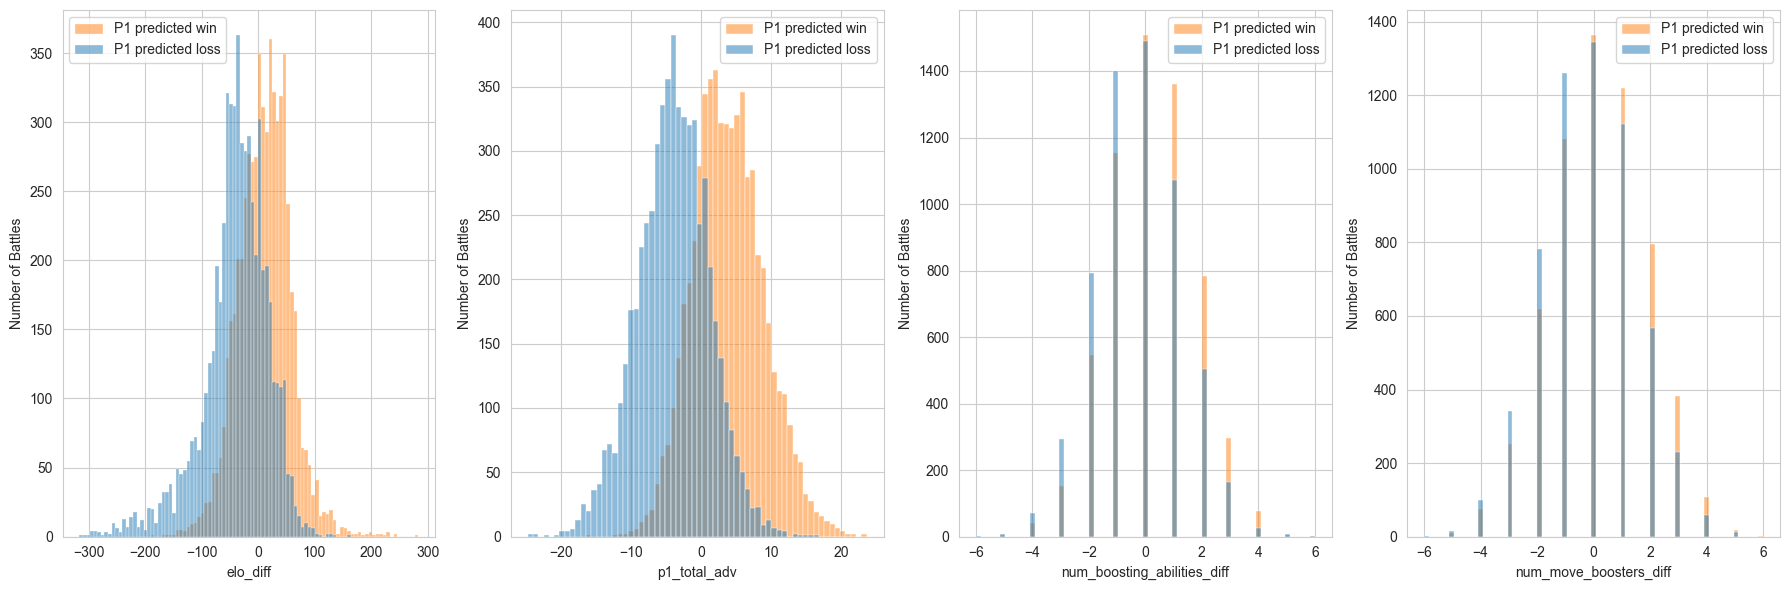

In [18]:
train_df["predictions"] = best_model.predict(X_train)

fig,axs = plt.subplots(ncols=4,sharey=False,figsize=(18,6))
sns.histplot(data = train_df,x='elo_diff',hue='predictions',ax=axs[0])
sns.histplot(data=train_df,x='p1_total_adv',hue='predictions',ax=axs[1])
sns.histplot(data = train_df, x = 'num_boosting_abilities_diff',hue='predictions',ax=axs[2])
sns.histplot(data=train_df,x='num_move_boosters_diff',hue='predictions',ax=axs[3])

for i in range(4):
    axs[i].set_ylabel("Number of Battles")
    axs[i].legend(labels=["P1 predicted win","P1 predicted loss"])

plt.tight_layout()
plt.show()


# Section 4: Performance on Test Data

We now take our best model, which has already been fit to the training data, and compute its accuracy score and confusion matrix on the test data.

In [19]:
X_test = test_df[['elo_diff','p1_total_adv','num_move_boosters_diff','num_boosting_abilities_diff']]
y_test = test_df['p1_win']

y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred,normalize='all')

print(f"The {best_model_name} predicted the winners in the test set with an accuracy score of {acc}.")
print(f"The confusion matrix of {best_model_name} is")
print(cm)

The unbiased logistic regression predicted the winners in the test set with an accuracy score of 0.5356154039768437.
The confusion matrix of unbiased logistic regression is
[[0.25899824 0.23609363]
 [0.22829096 0.27661717]]
